# **Machine Learning Project PART 2 | ATU Winter 2024**  
**Author**: Lais Coletta Pereira  
**Lecturer**: Brian McGinley  

---

# Data Pre-processing

The first task will be to build a dataset from the annotated data. Here are the steps taken in this notebook:

1. **Extract Spectrogram for Each Call**:
   - For each annotated call, extract a spectrogram and store it as a raw 2D array (not as an image).
   - Use the frequency range specified in the annotations to ensure spectrograms are aligned in terms of time and frequency.
   - Save metadata with each spectrogram (e.g., annotation, category, frequency, time range).

2. **Pre-Processing for Longest and Broadest Spectrogram**:
   - Identify the longest call (by duration) and the broadest (by frequency) call.
   - Use these to set baseline spectrogram dimensions, ensuring consistency across all spectrograms.

3. **Saving Spectrograms as 2D Arrays**:
   - Processed spectrograms will be saved as `.npz` files (which store both the spectrogram and metadata) in their respective directories.

4. **Create Spectrograms for "No-Call" Segments**: Spectrograms created for time periods without annotated calls.

5. **Metadata Storage**: For each spectrogram, associated metadata (e.g., annotation, call type, start and end times, frequency range) should be stored alongside it.

6. **Ensure Uniform Spectrogram Size**: Spectrograms will be resized (padded or cropped) to match the baseline dimensions based on the longest time duration and broadest frequency range.


In [160]:
# Standard library imports
import os
import pandas as pd
import numpy as np

# Scipy imports for handling audio processing
from scipy.io import wavfile
from scipy import signal

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# TensorFlow and Keras imports for deep learning models and utilities
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, Conv1D, MaxPooling2D, MaxPooling1D, Flatten, Dense, Dropout, 
    GlobalAveragePooling1D, GlobalAveragePooling2D, BatchNormalization, Add, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, VGG16, Xception
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn imports for preprocessing and data splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Utility imports
import seaborn as sns
from keras.utils import to_categorical

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import precision_recall_fscore_support

In [92]:
# Define output directory for spectrogram files and create it if not exists
output_dir = 'spectrogram_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

***Function to load audio and annotations, reads .wav and .txt annotation files:***

In [93]:
def load_audio_and_annotation(file_base_name):
    """
    Load the WAV audio file and its corresponding annotation file.
    
    Parameters:
        - file_base_name (str): Base path of the file without extension.
        
    Returns:
        - sample_rate (int): Sample rate of the audio file.
        - samples (np.array): Audio samples.
        - annotations (DataFrame): Annotations as a pandas DataFrame.
    """
    # Load the WAV audio file
    audio_path = file_base_name + '.wav'
    sample_rate, samples = wavfile.read(audio_path)
    
    # Load the annotation file (typically .txt or .csv)
    annot_file_path = file_base_name + '.Table.1.selections.txt'
    df = pd.read_csv(annot_file_path, sep='\t')
    
    return sample_rate, samples, df

**Function to extract audio segments based on annotations**

Extract audio segments based on start and end times from annotations, storing each segment along with its relevant information in a list.

In [22]:
def extract_audio_segments(samples, sample_rate, annotations):
    """
    Extracts audio segments based on the annotations.
    
    Parameters:
        - samples (np.array): The raw audio data.
        - sample_rate (int): The sample rate of the audio.
        - annotations (DataFrame): The annotation file data.
        
    Returns:
        - segments (list of dict): List of audio segments with annotation information.
    """
    segments = []
    for _, row in annotations.iterrows():
        start_time, end_time = row['Begin Time (s)'], row['End Time (s)']
        start_sample, end_sample = int(start_time * sample_rate), int(end_time * sample_rate)
        
        # Check if start and end indices are valid
        if start_sample >= end_sample or start_sample < 0 or end_sample > len(samples):
            print(f"Invalid segment: {start_time}-{end_time}s")
            continue
        
        segment = samples[start_sample:end_sample]
        segments.append({
            'Selection': row['Selection'],
            'Annotation': row['Annotation'],
            'Begin Time (s)': start_time,
            'End Time (s)': end_time,
            'audio_segment': segment,
            'Low Freq (Hz)': row['Low Freq (Hz)'],
            'High Freq (Hz)': row['High Freq (Hz)']
        })
    return segments

**Define a function to generate a spectrogram from the audio segment**

This function generates a spectrogram from an audio segment by applying the Short-Time Fourier Transform (STFT) using [scipy.signal.spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html). 
It allows us to specify the frequency range (fmin, fmax) and other parameters like window length, FFT points, and overlap to control the resolution of the spectrogram. The function returns frequency bins, time bins, and the spectrogram data (2D array).


In [23]:
def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=1024, nfft=2048, noverlap=512):  
    """
    Generates a spectrogram for a given audio segment.
    
    Parameters:
        - audio_segment (np.array): The raw audio data segment.
        - sample_rate (int): The sample rate of the audio.
        - fmin (int): The minimum frequency for the spectrogram (default 20 Hz).
        - fmax (int): The maximum frequency for the spectrogram (default 1000 Hz).
        - nperseg (int): The length of each segment for the FFT (default 1024).
        - nfft (int): The number of FFT points (default 2048).
        - noverlap (int): The number of points to overlap between segments (default 512).
        
    Returns:
        - frequencies (np.array): Frequency bins for the spectrogram.
        - times (np.array): Time bins for the spectrogram.
        - spectrogram_data (np.array): The 2D spectrogram data.
    """
    frequencies, times, spectrogram_data = signal.spectrogram(
        audio_segment, sample_rate, nperseg=nperseg, nfft=nfft, noverlap=noverlap, window='hann'
    )
    spectrogram_data = np.maximum(spectrogram_data, 1e-10)
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    return frequencies[freq_slice], times, spectrogram_data[freq_slice]

***Calculate Baselines***

The function `calculate_baselines` computes baseline parameters (`max_time` and `max_frequency`) across all files in the provided folder paths. These baselines are essential for ensuring consistent dimensions for spectrogram processing.

1. Global Variables Initialization:
- `max_time`: Tracks the longest duration of an audio segment.
- `max_frequency`: Tracks the largest frequency range across all audio segments.

2. Folder Iteration:
- The function iterates over the given list of `folder_paths`.  
- Inside each folder, it checks for files with a `.wav` extension.

3. File Processing:
- For each `.wav` file, its base name is derived to find and load its corresponding annotation file using the `load_audio_and_annotation` function.  
  - *The base path is constructed by removing the file extension.*

4. Annotation Segments Analysis:
- Segments are extracted from the audio and annotations using the `extract_audio_segments` function.  
- For each segment:
  - The duration is calculated as `End Time (s) - Begin Time (s)`, updating `max_time` if the duration is greater than the current value.
  - The frequency range is calculated as `High Freq (Hz) - Low Freq (Hz)`, updating `max_frequency` if the range is greater than the current value.

In [24]:
def calculate_baselines(folder_paths):
    """
    Calculate the baseline segment duration and frequency range across all files in the folder paths.
    """
    global max_time, max_frequency
    
    max_time, max_frequency = 0, 0
    
    # Iterate through each folder in the folder_paths list
    for folder_path in folder_paths:
        # Loop through each file in the current folder
        for file in os.listdir(folder_path):
            if file.endswith('.wav'):
                file_base_name = os.path.splitext(file)[0]
                file_base_path = os.path.join(folder_path, file_base_name)
                
                # Load the audio and annotation
                sample_rate, samples, df = load_audio_and_annotation(file_base_path)
                
                # Extract segments for the current file
                segments = extract_audio_segments(samples, sample_rate, df)
                
                # Find the longest duration in terms of time
                for segment in segments:
                    max_time = max(max_time, segment['End Time (s)'] - segment['Begin Time (s)'])
                    max_frequency = max(max_frequency, segment['High Freq (Hz)'] - segment['Low Freq (Hz)'])

***Padding or Cropping Spectrograms***

This function ensures that a spectrogram has a consistent shape by either padding or cropping along both time and frequency axes. It calculates the dimensions based on a baseline time and frequency range, which are derived from the longest call in time and the broadest frequency range across all the segments. It then adjusts the spectrogram's time bins to match the maximum duration, and ensures the correct frequency bins are present by resizing according to the broadest frequency range. 

In [25]:
def pad_or_crop_spectrogram(spectrogram_data, target_shape):
    """
    Pads or crops the spectrogram to match a target shape (frequency, time).
    
    Parameters:
        - spectrogram_data (np.array): The 2D spectrogram to be padded or cropped.
        - target_shape (tuple): The target shape (frequency, time).
        
    Returns:
        - padded_spectrogram (np.array): The padded or cropped spectrogram.
    """
    # Ensure spectrogram data is a numpy array
    spectrogram_data = np.array(spectrogram_data)

    # Check if the spectrogram is 2D (frequency x time)
    if spectrogram_data.ndim == 2:
        current_shape = spectrogram_data.shape
        padded_spectrogram = np.zeros(target_shape)

        # Check if the current spectrogram size is within bounds
        for i in range(min(current_shape[0], target_shape[0])):  # Frequencies
            for j in range(min(current_shape[1], target_shape[1])):  # Time steps
                padded_spectrogram[i, j] = float(spectrogram_data[i, j])
        return padded_spectrogram
    else:
        print(f"Error: Spectrogram data has invalid dimensions {spectrogram_data.shape}. Expected 2D.")
        raise ValueError(f"Spectrogram data must be 2D with dimensions (frequency, time), but got shape {spectrogram_data.shape}.")

***Create "No Call" Segments***

Identify the periods where no calls are made by analyzing the gaps between annotated call segments. It extracts the "no-call" portions from the audio samples and returns them as separate segments. The function handles any remaining no-call period after the last annotation and returns a list of the segmented intervals with no calls.

In [26]:
def create_no_call_segments(samples, sample_rate, call_annotations, silence_duration_threshold=0.5):
    """
    Create 'no-call' segments as periods of silence based on gaps in call annotations.
    
    Parameters:
        - samples (np.array): The raw audio data.
        - sample_rate (int): The sample rate of the audio.
        - call_annotations (DataFrame): The annotation data with call times.
        - silence_duration_threshold (float): Minimum gap (in seconds) to classify as 'no-call'.
    
    Returns:
        - no_call_segments (list): List of audio segments labeled as "no-call".
        - no_call_metadata (list of tuples): (start_time, end_time) for each "no-call" segment.
    """
    # Get the end times of existing calls
    call_end_times = call_annotations['End Time (s)'].values
    call_start_times = call_annotations['Begin Time (s)'].values
    
    # Sort calls by start times (just in case)
    sorted_start_times = np.sort(call_start_times)
    sorted_end_times = call_end_times[np.argsort(call_start_times)]
    
    # Generate the 'no-call' periods by looking at gaps between successive call end times and next start times
    no_call_segments = []
    for i in range(len(sorted_start_times) - 1):
        end_of_previous_call = sorted_end_times[i]
        start_of_next_call = sorted_start_times[i + 1]
        
        # Check for gaps larger than the silence threshold
        if start_of_next_call - end_of_previous_call > silence_duration_threshold:
            # Append the no-call segment between two calls
            start_sample = int(end_of_previous_call * sample_rate)
            end_sample = int(start_of_next_call * sample_rate)
            no_call_segment = samples[start_sample:end_sample]
            no_call_segments.append(no_call_segment)
    
    # Add the silent period after the last call
    last_call_end_time = sorted_end_times[-1]
    audio_duration = len(samples) / sample_rate
    if audio_duration - last_call_end_time > silence_duration_threshold:
        start_sample = int(last_call_end_time * sample_rate)
        no_call_segment = samples[start_sample:]
        no_call_segments.append(no_call_segment)

    return no_call_segments


***Categorise annotation name***

Determines the category name based on the annotation name instead of the folder name.

In [27]:
def get_category_name(annotation):
    category_mapping = {
        'Rupe A': 'rupe_A',
        'Rupe B': 'rupe_B',
        'Rupe C': 'rupe_C',
        'Growl B': 'growl_B',
        'Moan': 'moan',
        'G rupe': 'g_rupe',
        'Guttural rupe': 'g_rupe',
        'no_call': 'no_call',  
        'Type 4 A': 'type_4_A'
    }
    # Logging the unknown category
    if annotation not in category_mapping:
        print(f"Unknown annotation found: {annotation}")
    return category_mapping.get(annotation, 'unknown')

***Load files, process audio, generate spectrograms, padding/cropping and saving the data:***

In [28]:
# Folder paths for the WAV and annotation files
folder_paths = [
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Guttural rupe',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Moan'
]

dataset = []

# Calculate the baseline values for time and frequency
calculate_baselines(folder_paths)

# Now, max_time and max_frequency contain the baseline values
target_shape = (int(max_frequency), int(max_time))

# Process audio files and annotations
for folder_path in folder_paths:
    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            file_base_name = os.path.splitext(file)[0]
            file_base_path = os.path.join(folder_path, file_base_name)
            sample_rate, samples, df = load_audio_and_annotation(file_base_path)
            segments = extract_audio_segments(samples, sample_rate, df)

            # Generate no_call segments from silent gaps
            no_call_segments = create_no_call_segments(samples, sample_rate, df)
            
            # Combine call and no-call segments
            for audio_segment in no_call_segments:
                segments.append({
                    'Selection': 'no_call',  # Use 'no_call' as the selection for silent segments
                    'Annotation': 'no_call',
                    'Begin Time (s)': 0,
                    'End Time (s)': len(audio_segment) / sample_rate,
                    'audio_segment': audio_segment,
                    'Low Freq (Hz)': 0,
                    'High Freq (Hz)': sample_rate // 2
                })
            
            # Categorize segments and add to the dataset
            for segment in segments:
                category = get_category_name(segment['Annotation'])
                segment['Category'] = category
                dataset.append(pd.DataFrame([segment]))

# Concatenate all segment data into a single DataFrame
final_df = pd.concat(dataset, ignore_index=True)

# Save spectrograms for all segments
for _, segment_info in final_df.iterrows():
    audio_segment = segment_info['audio_segment']
    frequencies, times, spectrogram_data = generate_spectrogram(
        audio_segment, sample_rate, fmin=segment_info['Low Freq (Hz)'], fmax=segment_info['High Freq (Hz)']
    )
    
    # Pad or crop the spectrogram to match the maximum size
    try:
        padded_spectrogram = pad_or_crop_spectrogram(spectrogram_data, target_shape)
    except ValueError as e:
        print(f"Error while processing {segment_info['Selection']} ({segment_info['Category']}): {e}")
        continue

    # Save spectrogram to an NPZ file
    npz_filename = f"{segment_info['Category']}_{segment_info['Begin Time (s)']}_{segment_info['End Time (s)']}.npz"
    npz_file_path = os.path.join(output_dir, npz_filename)
    np.savez(npz_file_path, spectrogram_data=padded_spectrogram, frequencies=frequencies, times=times)


Unknown annotation found: nan
Unknown annotation found: nan
Unknown annotation found: Type 4 B
Unknown annotation found: unidentified
Unknown annotation found: Trrot
Unknown annotation found: Unidentified
Unknown annotation found: Trrot
Unknown annotation found: Trrot
Unknown annotation found: Trrot
Unknown annotation found: ??
Unknown annotation found: ?
Unknown annotation found: ?
Unknown annotation found: ??
Unknown annotation found: HS Groan
Unknown annotation found: HS Groan


### Spectrograms 
Reference code: spectrogram.ipynb 

This code processes grey seal call `.wav` files by generating spectrograms using `scipy.signal.spectrogram` with customizable parameters such as segment length, overlap, and frequency range (e.g., 20–1000 Hz). Annotations are loaded from accompanying `.txt` files and visualized on the spectrogram using `matplotlib.patches.Rectangle`, where each annotation is color-coded for clarity. This approach facilitates both spectral and temporal analysis of calls. 

#### Guttural Rupe

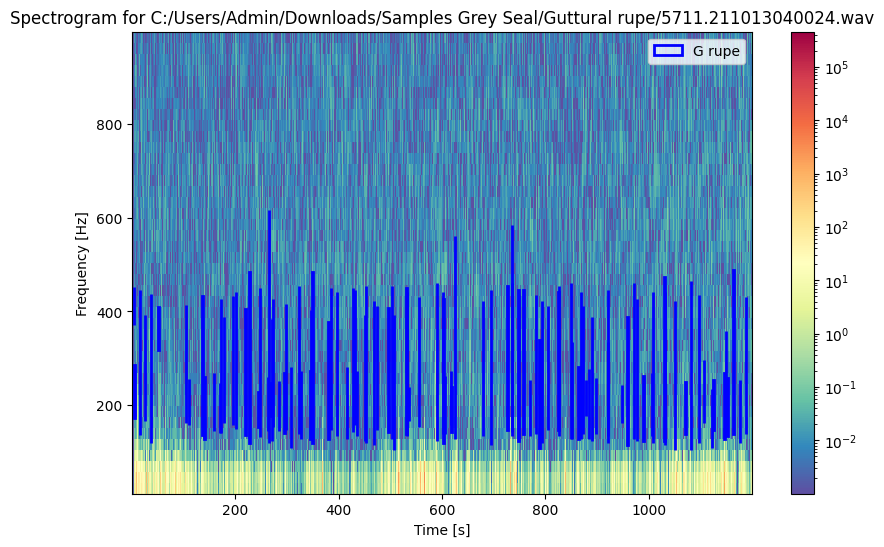

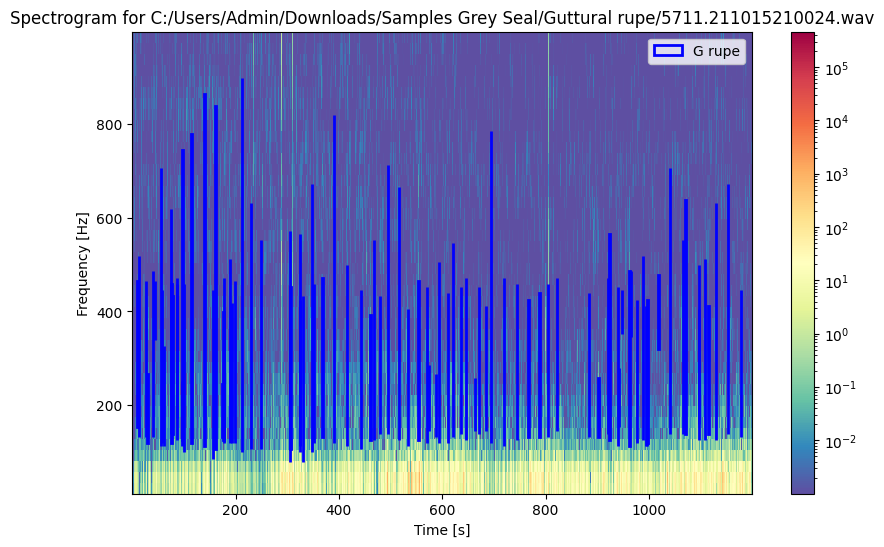

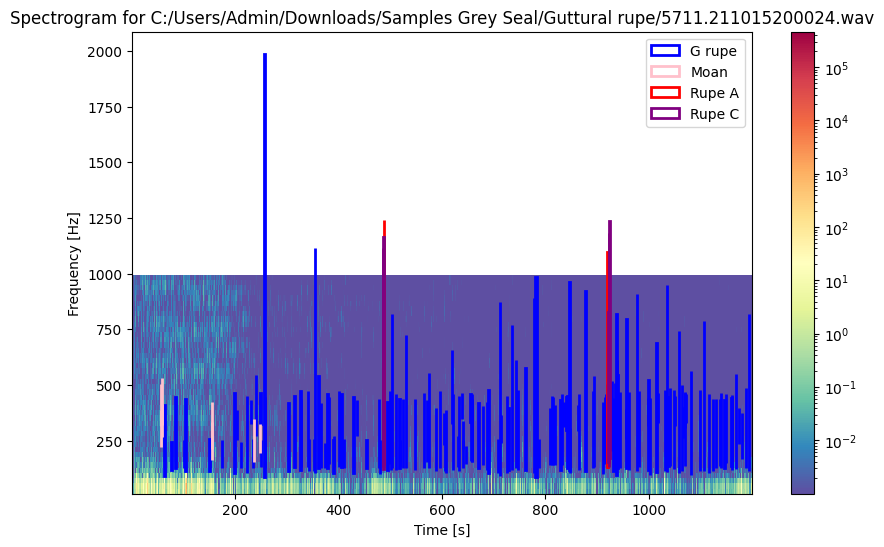

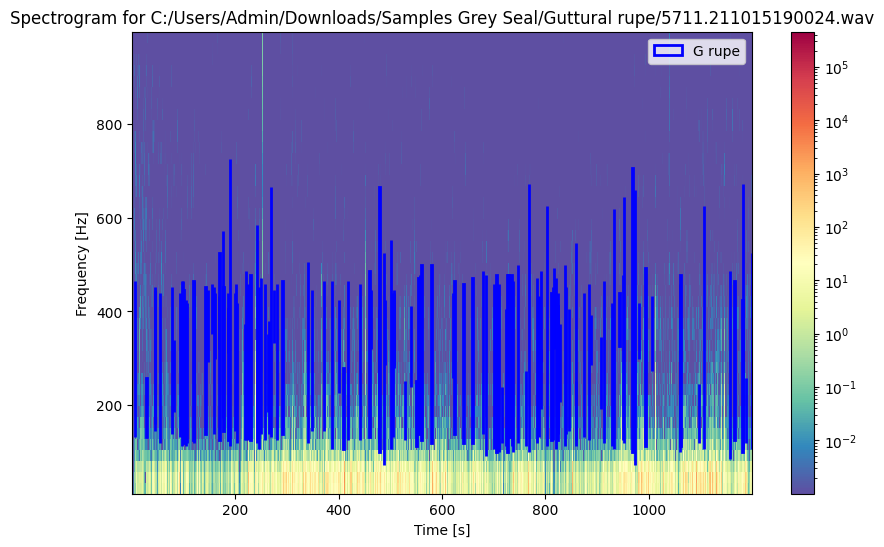

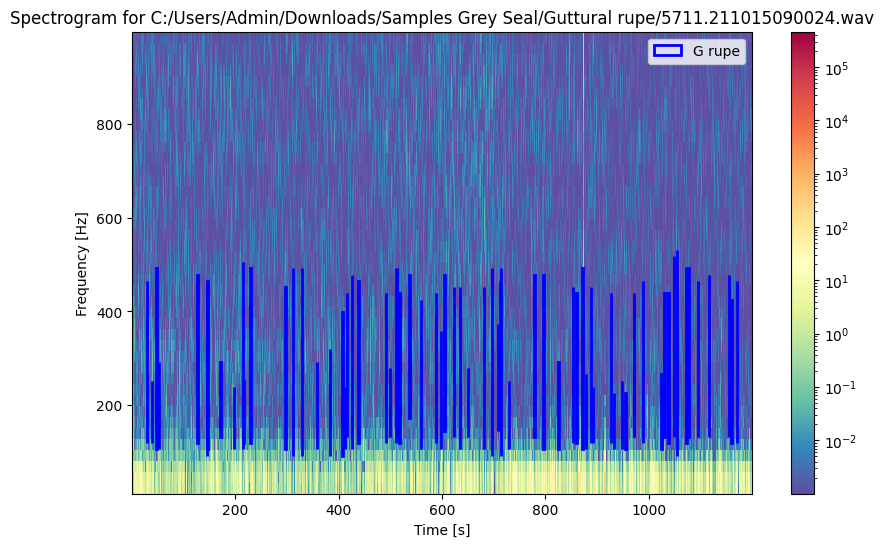

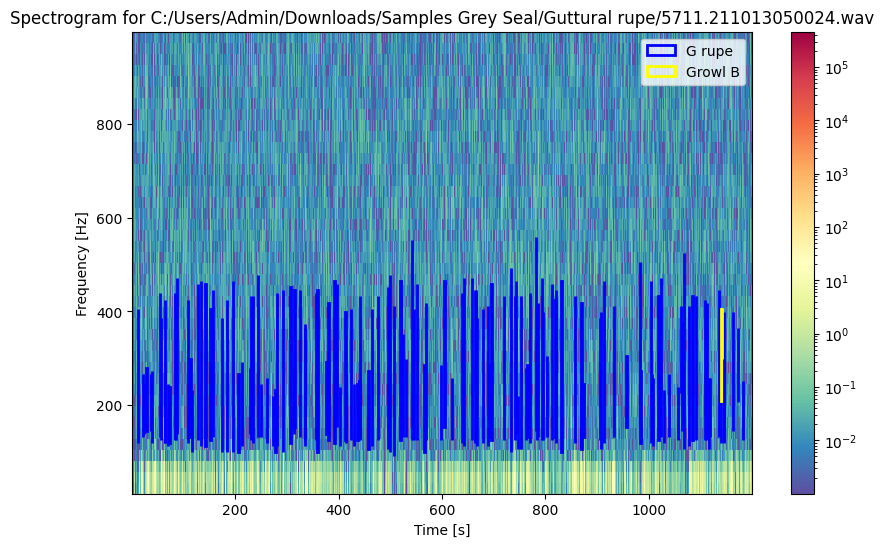

In [14]:
# File paths for the WAV files
file_paths = [
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211013040024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015210024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015200024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015190024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015090024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211013050024.wav"
]

# Define colors for annotations
annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Function to generate spectrogram
def generate_spectrogram(samples, sample_rate):
    frequencies, times, spectrogram = signal.spectrogram(samples, sample_rate, nperseg=2456, nfft=4096, noverlap=1228, window='hann')
    spectrogram[spectrogram < 0.001] = 0.001  # Trim off tiny values for a proper display

    # Trim in frequency
    fmin, fmax = 20, 1000  # Hz
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram = spectrogram[freq_slice, :][0]

    return frequencies, times, spectrogram

# Function to overlay annotations on the spectrogram
def overlay_annotations(ax, df, annotation_colors):
    added_labels = set()  # Ensure each label is added once

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        if annotation not in annotation_colors:
            continue  # Skip unrecognized annotations

        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),
                end_time - start_time,
                high_freq - low_freq,
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None
            )
        )
        added_labels.add(annotation)

    ax.legend(loc='upper right')  # Add a legend to the plot

# Iterate over each file
for file in file_paths:
    sample_rate, samples = wavfile.read(file)
    annot_file_path = file.replace('.wav', '.Table.1.selections.txt')
    
    # Read the annotations file into a DataFrame
    df = pd.read_csv(annot_file_path, sep='\t')

    # Generate the spectrogram
    frequencies, times, spectrogram = generate_spectrogram(samples, sample_rate)

    # Create the spectrogram plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pc = ax.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = fig.colorbar(pc)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')

    # Overlay annotations on the spectrogram
    overlay_annotations(ax, df, annotation_colors)

    # Display the spectrogram
    plt.title(f"Spectrogram for {file}")
    plt.show()


#### Rupe A and B

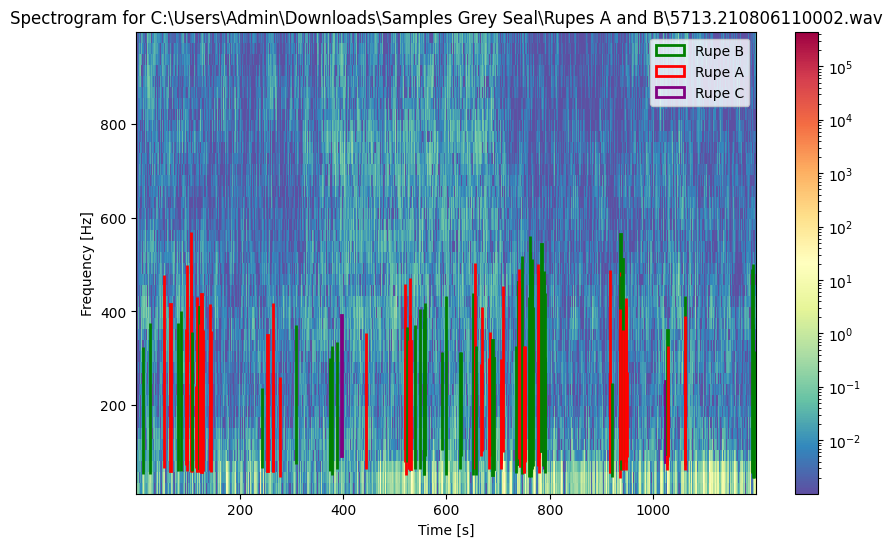

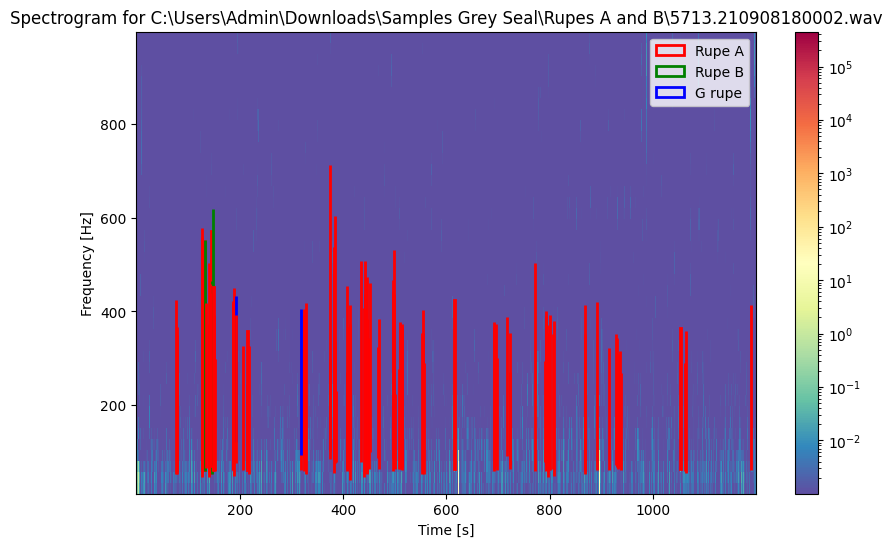

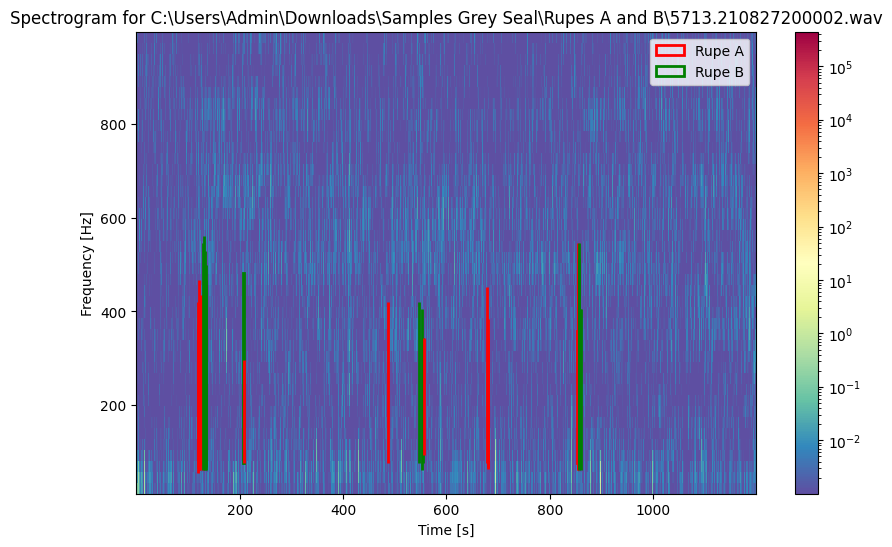

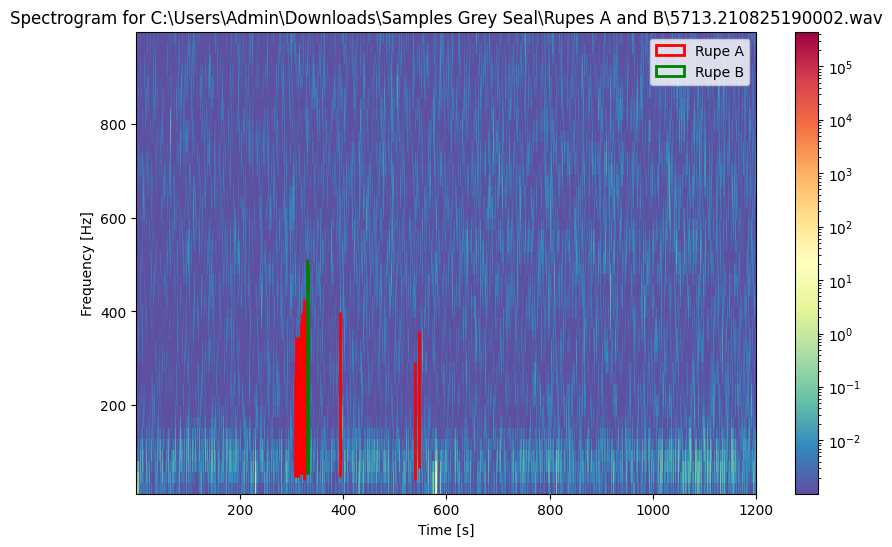

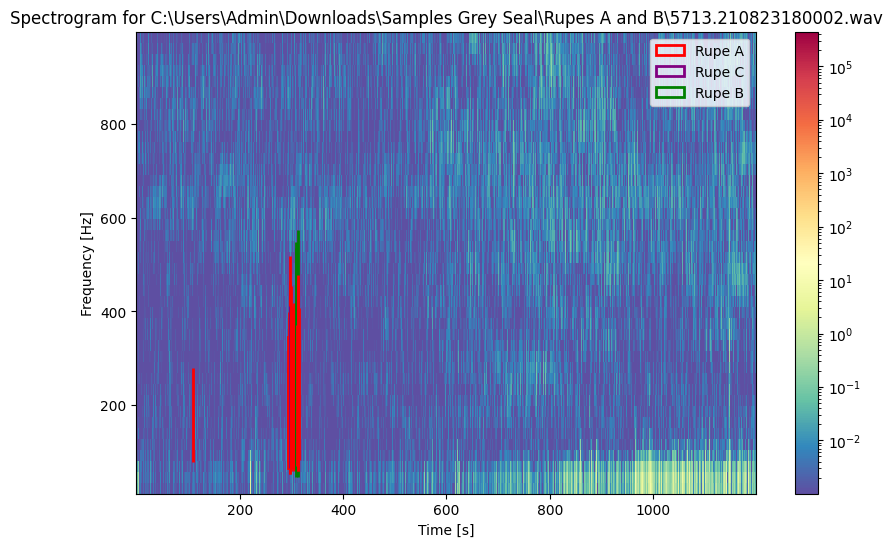

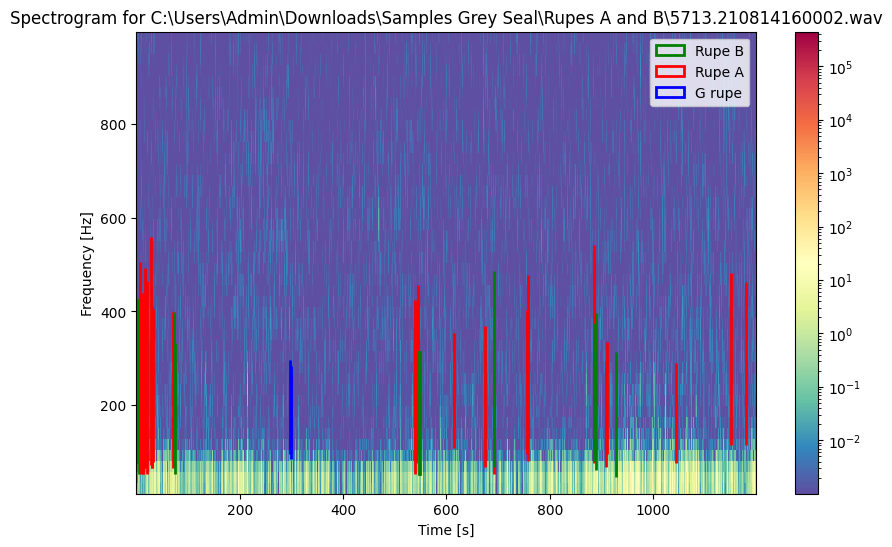

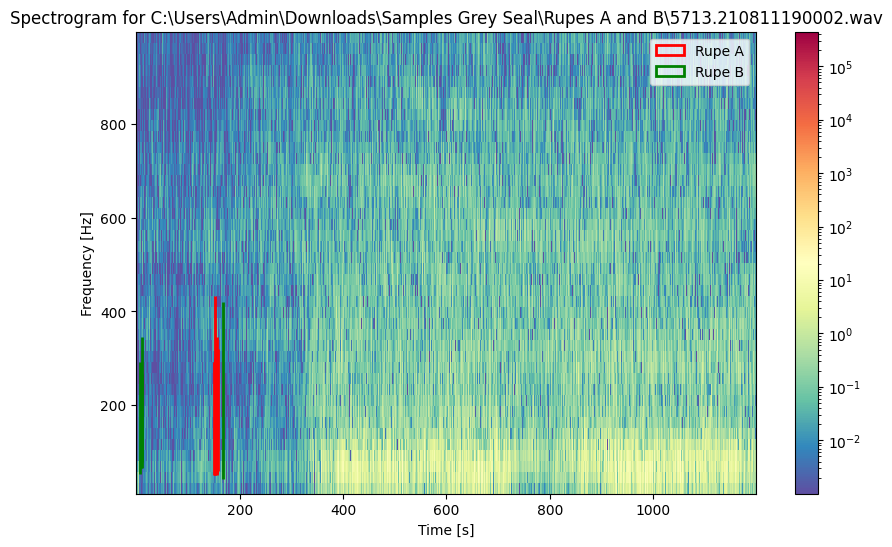

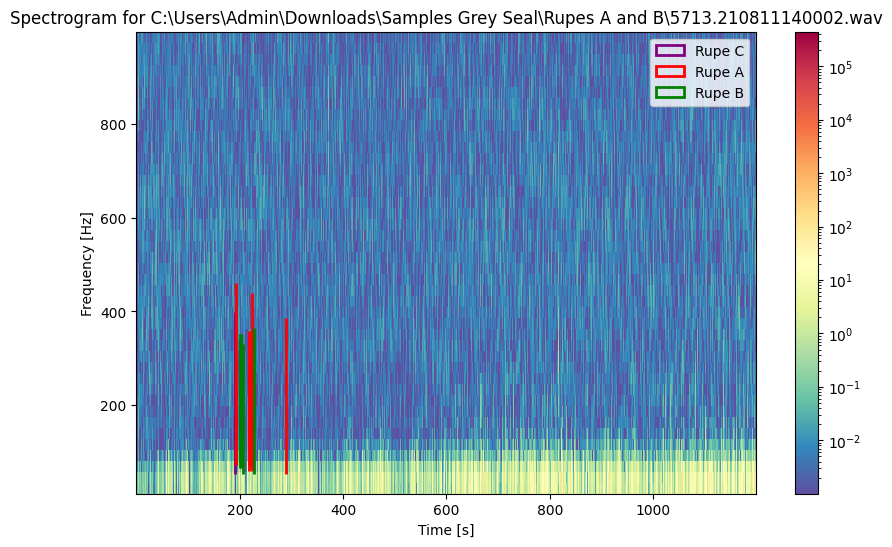

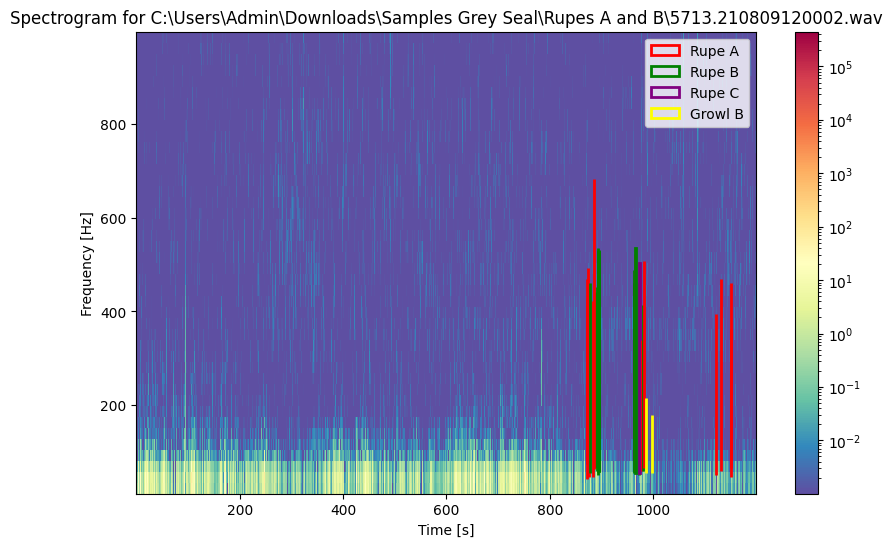

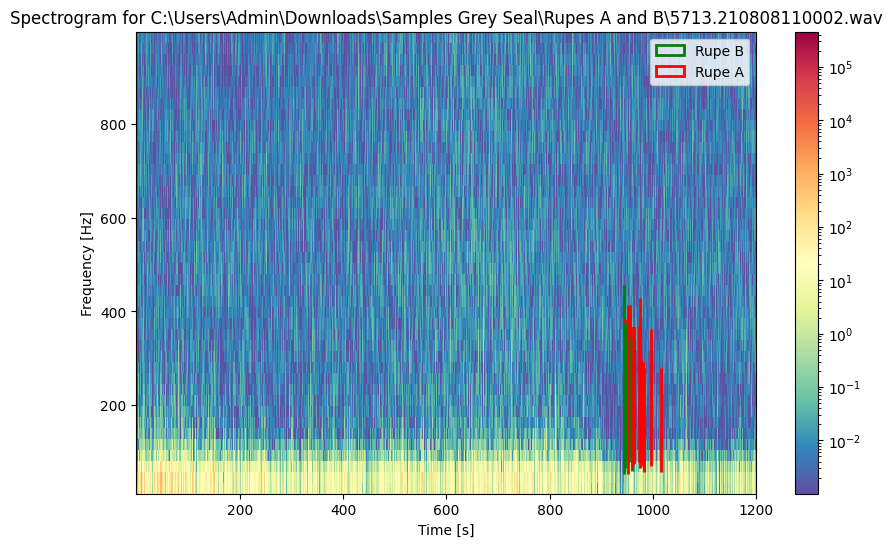

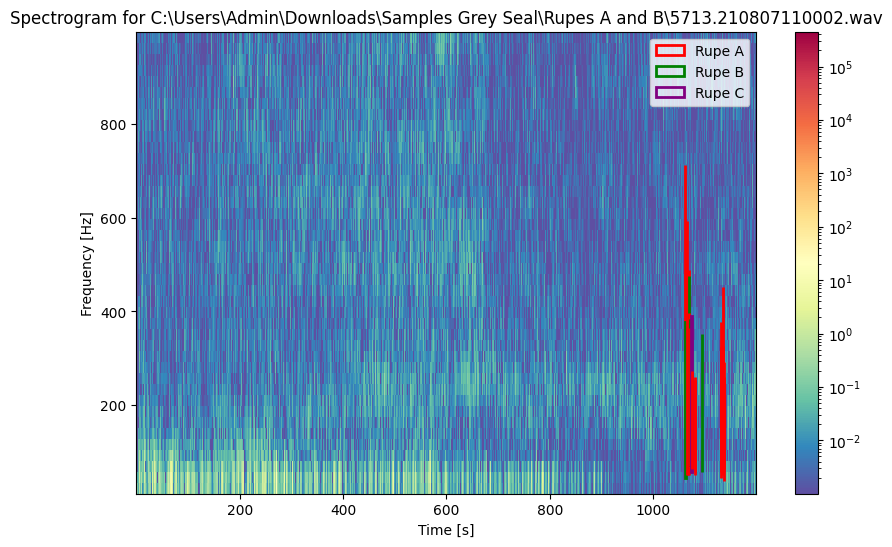

In [12]:
# File paths for the WAV files
file_paths = [
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210806110002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210908180002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210827200002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210825190002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210823180002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210814160002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210811190002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210811140002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210809120002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210808110002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210807110002.wav"
]

# Define colors for annotations
annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Function to generate spectrogram
def generate_spectrogram(samples, sample_rate):
    frequencies, times, spectrogram = signal.spectrogram(samples, sample_rate, nperseg=2456, nfft=4096, noverlap=1228, window='hann')
    spectrogram[spectrogram < 0.001] = 0.001  # Trim off tiny values for a proper display

    # Trim in frequency
    fmin, fmax = 20, 1000  # Hz
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram = spectrogram[freq_slice, :][0]

    return frequencies, times, spectrogram

# Function to overlay annotations on the spectrogram
def overlay_annotations(ax, df, annotation_colors):
    added_labels = set()  # Ensure each label is added once

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        if annotation not in annotation_colors:
            continue  # Skip unrecognized annotations

        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),
                end_time - start_time,
                high_freq - low_freq,
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None
            )
        )
        added_labels.add(annotation)

    ax.legend(loc='upper right')  # Add a legend to the plot

# Iterate over each file
for file in file_paths:
    sample_rate, samples = wavfile.read(file)
    annot_file_path = file.replace('.wav', '.Table.1.selections.txt')
    
    # Read the annotations file into a DataFrame
    df = pd.read_csv(annot_file_path, sep='\t')

    # Generate the spectrogram
    frequencies, times, spectrogram = generate_spectrogram(samples, sample_rate)

    # Create the spectrogram plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pc = ax.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = fig.colorbar(pc)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')

    # Overlay annotations on the spectrogram
    overlay_annotations(ax, df, annotation_colors)

    # Display the spectrogram
    plt.title(f"Spectrogram for {file}")
    plt.show()


#### Moan

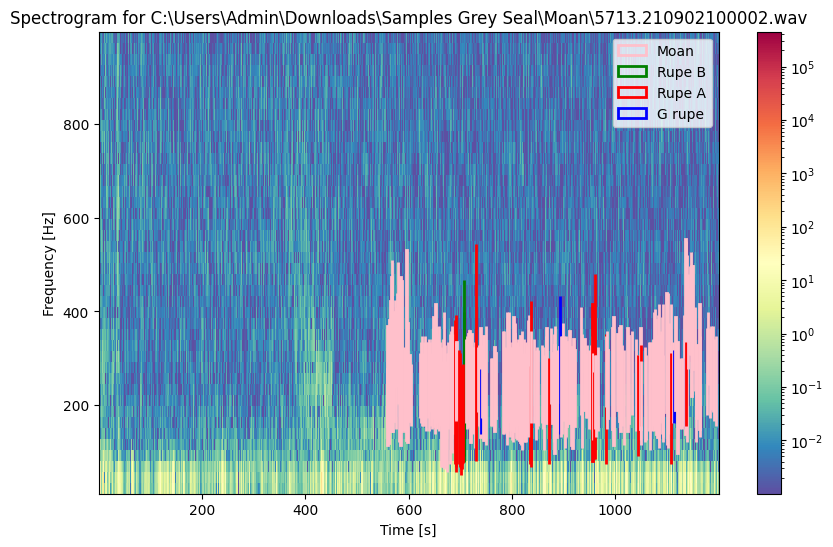

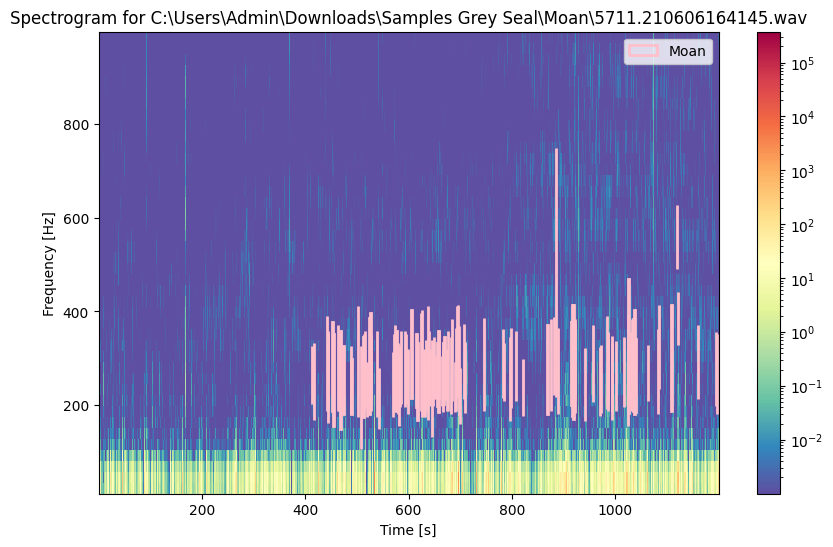

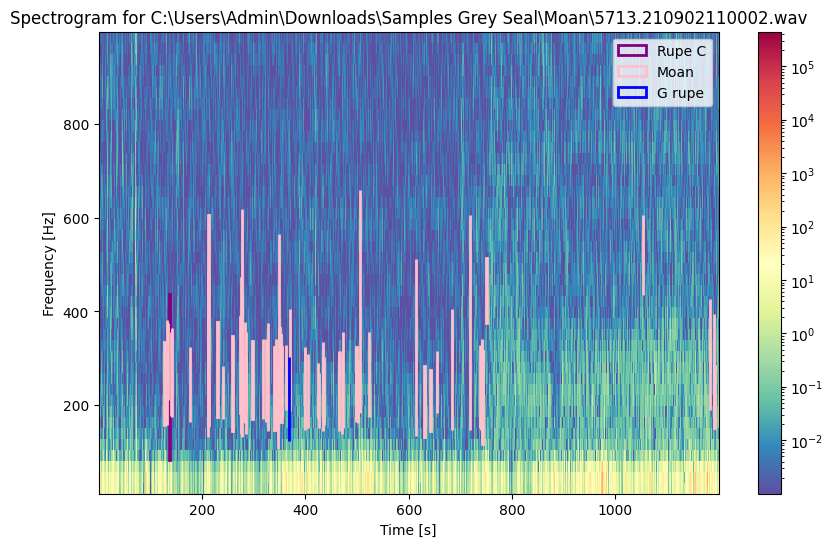

In [13]:
# File paths for the WAV files (Moan category)
file_paths = [
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Moan\5713.210902100002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Moan\5711.210606164145.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Moan\5713.210902110002.wav"
]

# Define colors for annotations
annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Function to generate spectrogram
def generate_spectrogram(samples, sample_rate):
    frequencies, times, spectrogram = signal.spectrogram(samples, sample_rate, nperseg=2456, nfft=4096, noverlap=1228, window='hann')
    spectrogram[spectrogram < 0.001] = 0.001  # Trim off tiny values for a proper display

    # Trim in frequency
    fmin, fmax = 20, 1000  # Hz
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram = spectrogram[freq_slice, :][0]

    return frequencies, times, spectrogram

# Function to overlay annotations on the spectrogram
def overlay_annotations(ax, df, annotation_colors):
    added_labels = set()  # Ensure each label is added once

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        if annotation not in annotation_colors:
            continue  # Skip unrecognized annotations

        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),
                end_time - start_time,
                high_freq - low_freq,
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None
            )
        )
        added_labels.add(annotation)

    ax.legend(loc='upper right')  # Add a legend to the plot

# Iterate over each file
for file in file_paths:
    sample_rate, samples = wavfile.read(file)
    annot_file_path = file.replace('.wav', '.Table.1.selections.txt')
    
    # Read the annotations file into a DataFrame
    df = pd.read_csv(annot_file_path, sep='\t')

    # Generate the spectrogram
    frequencies, times, spectrogram = generate_spectrogram(samples, sample_rate)

    # Create the spectrogram plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pc = ax.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = fig.colorbar(pc)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')

    # Overlay annotations on the spectrogram
    overlay_annotations(ax, df, annotation_colors)

    # Display the spectrogram
    plt.title(f"Spectrogram for {file}")
    plt.show()


---
# Step 2 - Model Training
***Dataset Loading Function***

Load spectrogram data from the `.npz` files. It excludes "unknown", "growl_B", "rupe_C" and "Type_4_A" files and maps annotations correctly.

In [99]:
import os
import numpy as np
import pandas as pd

def load_dataset(output_dir, final_df):
    """
    Loads spectrogram data and their corresponding labels from .npz files, 
    linking them to final_df created in code 1.

    Parameters:
        - output_dir (str): Directory containing .npz files.
        - final_df (pd.DataFrame): DataFrame with category and annotation info.

    Returns:
        - spectrograms (np.ndarray): Array of spectrogram data.
        - labels (np.ndarray): Array of corresponding labels.
    """
    spectrograms = []
    labels = []

    # Filter categories with fewer than 30 samples
    valid_categories = final_df["Category"].value_counts()
    valid_categories = valid_categories[valid_categories >= 30].index
    final_df_filtered = final_df[final_df["Category"].isin(valid_categories)]

    # List unique categories in filtered final_df
    available_categories = final_df_filtered["Category"].unique()

    for file in os.listdir(output_dir):
        if file.endswith(".npz"):
            try:
                # Load data
                data = np.load(os.path.join(output_dir, file))
                spectrogram_data = data["spectrogram_data"]

                # Extract category label from filename
                category_label = '_'.join(file.split('_')[:-2])  # Remove timestamp

                # Match with filtered final_df
                segment_row = final_df_filtered[final_df_filtered['Category'] == category_label]
                if not segment_row.empty:
                    category = segment_row.iloc[0]['Category']
                    spectrograms.append(spectrogram_data)
                    labels.append(category)

            except KeyError:
                continue

    return np.array(spectrograms, dtype=object), np.array(labels)


def summarize_data(spectrograms, labels):
    """
    Summarizes the loaded spectrograms and their corresponding labels.

    Parameters:
        - spectrograms (np.ndarray): Array of spectrogram data.
        - labels (np.ndarray): Array of corresponding labels.
    """
    labels_df = pd.DataFrame(labels, columns=["Category"])

    num_samples = len(spectrograms)
    unique_labels = labels_df["Category"].nunique()
    category_counts = labels_df["Category"].value_counts()

    summary = (
        f"Total number of samples: {num_samples}\n"
        f"Unique categories: {unique_labels}\n\n"
        f"Category distribution:\n{category_counts.to_string()}"
    )
    print(summary)

# Example usage of the functions
spectrograms, labels = load_dataset(output_dir, final_df)
summarize_data(spectrograms, labels)


Total number of samples: 3062
Unique categories: 5

Category distribution:
Category
no_call    1414
g_rupe      731
moan        426
rupe_A      368
rupe_B      123


***Data Preprocessing***

1. Flattening the Spectrograms: Converts 2D spectrograms into 1D arrays for model input.
2. Label Encoding: Converts categorical labels (e.g., 'rupe_A') into numerical values.
3. Normalization: Scales the spectrograms' pixel values to a range between 0 and 1 for better model performance.
4. Data Splitting: Divides the data into training and testing sets (80% for training, 20% for testing). The function returns the preprocessed spectrograms, labels, and a LabelEncoder instance for decoding categories.

In [142]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

def preprocess_data(spectrograms, labels):
    """
    Preprocess the spectrogram data by normalizing and splitting it into training and testing sets.
    
    Parameters:
        - spectrograms (np.ndarray): Array of spectrogram data.
        - labels (np.ndarray): Array of corresponding labels.

    Returns:
        - X_train, X_test (np.ndarray): Normalized training and testing spectrogram data.
        - y_train, y_test (np.ndarray): Corresponding labels for training and testing data.
        - label_encoder (LabelEncoder): The fitted label encoder used to encode the labels.
    """
    # Flatten spectrogram data if needed (for deep learning models, you often need to reshape to 2D or 1D)
    X = np.array([spec.flatten() for spec in spectrograms], dtype=np.float32)
    
    # Encode labels as integers
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(labels)

    # Normalize the spectrogram data
    scaler = MinMaxScaler(feature_range=(0, 1))  # Normalize between 0 and 1
    X_normalized = scaler.fit_transform(X)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

    # Return the necessary data (adding label_encoder to the return values)
    return X_train, X_test, y_train, y_test, label_encoder


# Example usage
X_train, X_test, y_train, y_test, label_encoder = preprocess_data(spectrograms, labels)

# Output the shapes of the data after preprocessing
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")


Training data shape: (2449, 14876)
Test data shape: (613, 14876)
Training labels shape: (2449,)
Test labels shape: (613,)


***Building the Neural Network Model***

Creates a simple Convolutional Neural Network architecture for multi-class classification.

In [ ]:
# Reshape spectrograms for Conv2D input
X_train_reshaped = X_train.reshape((X_train.shape[0], spectrogram_height, spectrogram_width, 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], spectrogram_height, spectrogram_width, 1))

# Define the CNN architecture with Conv2D
model = Sequential(name="model_2")

# 1st Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(spectrogram_height, spectrogram_width, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Convolutional Layer
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the data for the Dense layers
model.add(Flatten())

# Fully connected (Dense) Layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))  # Regularization

# Output Layer for classification
num_classes = len(np.unique(y_train))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 14874, 128)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 7437, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 7435, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 3717, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 3715, 512)      │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 1857, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 950784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │   243,400,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,895,045 (930.39 MB)

 Trainable params: 243,895,045 (930.39 MB)

 Non-trainable params: 0 (0.00 B)

#### Training the Model

***Compile the model***

Optimizer: adam is a popular optimization algorithm that adjusts the learning rate based on training.
Loss function: sparse_categorical_crossentropy is appropriate for multi-class classification when labels are integers.
Metrics: Track accuracy during training.

In [145]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


***Training the model***
- Epochs: 30 Epochs are a common starting point to ensure the model has enough time to learn patterns from the data. If the model shows good performance early on (e.g., it stabilizes after just 10–15 epochs), we might shorten the training. [Source](https://stackoverflow.com/questions/35050753/how-big-should-batch-size-and-number-of-epochs-be-when-fitting-a-model)
- Batch size: The number of samples processed before the model's internal parameters are updated. This is set to 64 here.
- Validation data: The validation dataset is used to monitor the model's performance during training on unseen data.

In [146]:
# Train the model
model.fit(X_train_reshaped, y_train, epochs=30, batch_size=64, validation_data=(X_test_reshaped, y_test))

Epoch 1/30


KeyboardInterrupt: 

#### Evaluating the Model
Evaluate the trained model's performance on the test set and calculate accuracy.

In [88]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.4434 - loss: 2.0159
Test Accuracy: 0.4339


The accuracy is relatively close between the training and validation datasets, which means the model isn't overfitting. Therefore, I will not try **regularization**.

#### Visualizing Loss and Accuracy
Plot the training and validation loss/accuracy curves over the training epochs.

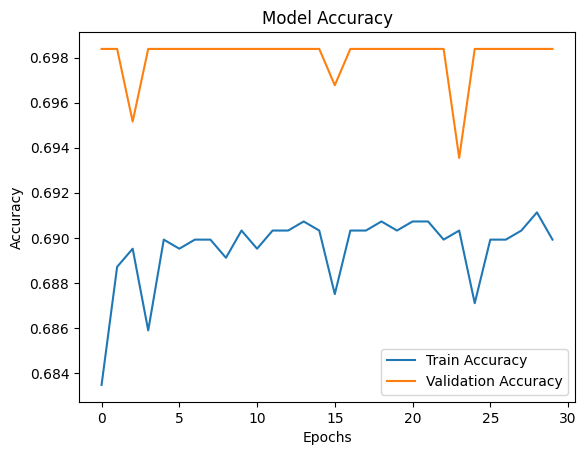

In [ ]:
import matplotlib.pyplot as plt

# Plotting accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


***Experiment with different hyper-parameters***

1. Input Parameters: X_train determines the input shape of the training data.
Hyperparameters (e.g., filters, kernel_size, etc.) define the model's architecture.

2. Network Layers: Adds three Conv1D layers, each followed by MaxPooling1D. The filters define the number of channels, and the kernel_size specifies the convolution window size.
Applies a Flatten layer to reshape the output from the convolutions into a 1D array.
Adds a fully connected (Dense) layer with neurons specified by dense_neurons.
Adds Dropout for regularization using the dropout_rate.

3. Output Layer: A softmax Dense layer with num_classes neurons for classification.
Compilation: Uses the Adam optimizer with learning_rate and the sparse categorical cross-entropy loss function.
Tracks accuracy as a metric during training.

In [147]:
# Function to create the model with hyperparameters
def create_model(X_train, num_classes, filters=(64, 128, 256), kernel_size=3, dropout_rate=0.5, learning_rate=0.001, batch_size=64, dense_neurons=64):
    """
    Build the CNN model based on provided hyperparameters for filters, kernel_size, dropout_rate, learning_rate, and dense_neurons.

    Parameters:
        - X_train (ndarray): Input spectrogram training data.
        - num_classes (int): Number of output classes.
        - filters (tuple): List of filter counts for the convolution layers.
        - kernel_size (int): Size of the convolution kernel.
        - dropout_rate (float): Dropout rate for regularization.
        - learning_rate (float): Learning rate for Adam optimizer.
        - batch_size (int): Batch size for model training.
        - dense_neurons (int): Number of neurons for the fully connected layer.
    
    Returns:
        - model (tf.keras.Model): Compiled CNN model ready for training.
    """
    model = Sequential()

    # First convolutional layer
    model.add(Conv1D(filters=filters[0], kernel_size=kernel_size, activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))

    # Second convolutional layer
    model.add(Conv1D(filters=filters[1], kernel_size=kernel_size, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    # Third convolutional layer
    model.add(Conv1D(filters=filters[2], kernel_size=kernel_size, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))

    # Flattening layer
    model.add(Flatten())

    # Fully connected layer
    model.add(Dense(dense_neurons, activation='relu'))
    model.add(Dropout(dropout_rate))  # Add dropout to regularize

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Compile model with Adam optimizer and sparse categorical crossentropy
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Function to run experiments for various hyperparameter configurations
def run_experiment(X_train, X_test, y_train, y_test, num_classes):
    """
    Runs an experiment with various configurations for filters, kernel size, learning rate, batch size, dropout rate, and dense neurons.
    
    Parameters:
        - X_train (ndarray): Training spectrogram data.
        - X_test (ndarray): Test spectrogram data.
        - y_train (ndarray): Training labels.
        - y_test (ndarray): Test labels.
        - num_classes (int): Number of output classes.

    Returns:
        - results (list): A list of dictionaries with configuration and accuracy for each model.
    """
    results = []

    # Hyperparameter search space
    filter_configs = [(32, 64, 128), (64, 128, 256), (128, 256, 512)]
    kernel_sizes = [3, 5, 7]
    learning_rates = [0.001, 0.0001, 0.01]
    batch_sizes = [32, 64, 128]
    dropout_rates = [0.3, 0.5, 0.7]
    dense_neurons = [32, 64, 128]

    # Run experiments across the configurations
    for filters in filter_configs:
        for kernel_size in kernel_sizes:
            for learning_rate in learning_rates:
                for batch_size in batch_sizes:
                    for dropout_rate in dropout_rates:
                        for neurons in dense_neurons:
                            print(f"\nTesting configuration: filters={filters}, kernel_size={kernel_size}, learning_rate={learning_rate}, batch_size={batch_size}, dropout_rate={dropout_rate}, dense_neurons={neurons}")

                            # Create model with current hyperparameters
                            model = create_model(X_train, num_classes, filters, kernel_size, dropout_rate, learning_rate, batch_size, neurons)

                            # Train the model
                            history = model.fit(X_train, y_train, epochs=10, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)

                            # Evaluate model on the test set
                            test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
                            print(f"Test Accuracy: {test_acc:.4f}")
                            
                            results.append({
                                'filters': filters,
                                'kernel_size': kernel_size,
                                'learning_rate': learning_rate,
                                'batch_size': batch_size,
                                'dropout_rate': dropout_rate,
                                'dense_neurons': neurons,
                                'accuracy': test_acc
                            })

    return results


X_train, X_test, y_train, y_test, label_encoder = preprocess_data(spectrograms, labels)

# Running the experiment with various hyperparameters
experiment_results = run_experiment(X_train, X_test, y_train, y_test, num_classes=5)

# Sort the results by accuracy and display top results
best_results = sorted(experiment_results, key=lambda x: x['accuracy'], reverse=True)

# Output top 5 results
for i, result in enumerate(best_results[:5]):
    print(f"Rank {i+1}: {result}")



Testing configuration: filters=(32, 64, 128), kernel_size=3, learning_rate=0.001, batch_size=32, dropout_rate=0.3, dense_neurons=32


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

#### Experiment with different CNN/Transfer Learning

***1. Custom CNN Architectures***

- Deeper Models: Increase the number of convolutional layers and filters or use deeper fully connected layers.
- Global Average Pooling: Instead of flattening after convolutional layers, use GlobalAveragePooling1D to reduce the number of parameters and avoid overfitting.
- Batch Normalization: Add batch normalization layers after convolutional layers to stabilize training.
- Residual Connections: Integrating residual connections can allow the model to learn more complex patterns.
- Calculate class weights to handle class imbalance
[Source](https://towardsdatascience.com/applied-deep-learning-part-4-convolutional-neural-networks-584bc134c1e2?gi=094c10ec515c#:~:text=The%20number%20of%20filters%20increase,as%20we%20use%20more%20filters.)

In [180]:
def build_experiment_model(input_shape, num_classes):
    model = Sequential()

    # First convolutional layer with BatchNormalization and MaxPooling
    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())  # Reference: https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization
    model.add(MaxPooling2D(pool_size=(2, 2)))  # Reference: https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPooling2D

    # Second convolutional layer with BatchNormalization and MaxPooling
    model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third convolutional layer with BatchNormalization and MaxPooling
    model.add(Conv2D(512, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Global Average Pooling instead of flattening
    model.add(GlobalAveragePooling2D())  # Reference: https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D

    # Fully connected layer with 256 units and ReLU activation
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))  # Dropout layer to prevent overfitting, with 50% rate

    # Output layer with 'softmax' activation function for classification
    model.add(Dense(num_classes, activation='softmax'))  # Reference: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

    # Compile the model with Adam optimizer and sparse categorical cross-entropy loss
    model.compile(optimizer=Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])  # Reference: https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

    return model

def train_model_with_class_weight(X_train_reshaped, y_train, X_test_reshaped, y_test):
    input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2], X_train_reshaped.shape[3])  # Input shape for 2D
    num_classes = len(np.unique(y_train))  # Number of unique categories in your labels
    
    # Initialize the model using the above-defined function
    model = build_experiment_model(input_shape, num_classes)

    # Calculate class weights to handle class imbalance
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(zip(np.unique(y_train), class_weights))

    # Initialize EarlyStopping to stop training if validation loss doesn't improve after 5 epochs
    early_stopping = EarlyStopping(monitor='val_loss',
                                   patience=5,  # stops after 5 epochs without improvement
                                   restore_best_weights=True)  # reverts to best weights

    # Train the model with the training and validation data
    history = model.fit(X_train_reshaped,
                        y_train,
                        epochs=10,  # Specify the number of epochs for training
                        validation_data=(X_test_reshaped, y_test),
                        class_weight=class_weight_dict,  # Implement class weights to address class imbalance
                        callbacks=[early_stopping])  # Implement early stopping callback

    # Evaluate the trained model on the test set
    loss, accuracy = model.evaluate(X_test_reshaped, y_test)
    print(f"Test Loss: {loss}")
    print(f"Test Accuracy: {accuracy}")
    
    # Save the trained model to a .h5 file
    model.save('experiment_model.h5')  # Saves the entire model

# Assuming your data is reshaped for 2D ConvNet model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2], X_train_reshaped.shape[3])  # (height, width, channels)
num_classes = len(np.unique(y_train))  # Number of unique categories in your labels

# Initialize the model using the above-defined function
model = build_experiment_model(input_shape, num_classes)

# Initialize EarlyStopping to stop training if validation loss doesn't improve after 5 epochs
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5,  # stops after 5 epochs without improvement
                               restore_best_weights=True)  # reverts to best weights

# Train the model with the training and validation data
history = model.fit(X_train_reshaped, 
                    y_train, 
                    epochs=10,  # Specify the number of epochs for training
                    validation_data=(X_test_reshaped, y_test),
                    callbacks=[early_stopping])  # Implement early stopping callback

# Evaluate the trained model on the test set
loss, accuracy = model.evaluate(X_test_reshaped, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# Save the trained model to a .h5 file
model.save('experiment_model.h5')  # Saves the entire model


Epoch 1/10
23/77 ━━━━━━━━━━━━━━━━━━━━ 33s 624ms/step - accuracy: 0.5306 - loss: 1.2243

KeyboardInterrupt: 

2.  Transfer Learning: Use Pre-Trained Models
**VGG16 Model**
VGG16 is a deep CNN architecture known for its simplicity and uniform structure. It consists of a series of convolutional layers with small 3x3 filters, followed by max-pooling layers, and then fully connected layers at the end. For transfer learning, we exclude the top fully connected layers and use the convolutional base with pretrained weights.

   - Efficiency: VGG16 has shown excellent performance in a variety of image classification tasks due to its simple architecture and depth.
   - Simple, yet Powerful: While more complex models exist, VGG16’s structure makes it easy to implement and fine-tune for different tasks, including audio classification (when used on spectrograms).
   - Generalizable: VGG16 works well on general visual features, making it a reasonable choice when the dataset is small or has fewer unique characteristics.

- [VGG16 Keras Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16)
- [VGG16 Paper](https://arxiv.org/abs/1409.1556)

**Xception Model**
Xception (Extreme Inception) is an architecture that builds on the concepts from Inception models but with a focus on depthwise separable convolutions. It has a large number of layers with fewer parameters and is designed for high accuracy, particularly in complex image tasks. Like VGG16, we discard the top classification layers and adapt the convolutional base for audio classification using spectrograms.

   - Efficiency: Xception's use of depthwise separable convolutions (rather than regular convolutions) drastically reduces the number of parameters, leading to faster training and potentially better generalization for smaller datasets.
   - State-of-the-art performance: Xception has demonstrated superior results in multiple visual tasks compared to VGG16, making it ideal for more complex tasks where precision is key.
   - Better Feature Extraction: Xception’s architecture is particularly well-suited to tasks that require the extraction of fine-grained patterns, which can be beneficial for interpreting spectrograms in audio classification.

- [Xception Keras Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/applications/Xception)
- [Xception Paper](https://arxiv.org/abs/1610.02357)

In [182]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.image import resize
import numpy as np
import matplotlib.pyplot as plt

# Function to preprocess spectrograms: Resize and add a third channel
def preprocess_spectrograms(spectrograms, target_size=(128, 128)):
    processed_spectrograms = []
    for spec in spectrograms:
        # Resize the spectrogram to the target size
        resized_spec = resize(spec, target_size).numpy()
        # Duplicate channels to create a 3-channel image
        expanded_spec = np.stack([resized_spec] * 3, axis=-1)
        processed_spectrograms.append(expanded_spec)
    return np.array(processed_spectrograms, dtype='float32')

# Assume `X_train` and `X_test` are loaded as lists of 2D spectrograms, `y_train` and `y_test` are labels
# Preprocess spectrograms to match the input format of pre-trained models
input_shape = (128, 128, 3)  # Target input shape for pre-trained models
X_train_processed = preprocess_spectrograms(X_train, target_size=(128, 128))
X_test_processed = preprocess_spectrograms(X_test, target_size=(128, 128))

# Normalize the data to [0, 1]
X_train_normalized = X_train_processed / 255.0
X_test_normalized = X_test_processed / 255.0

# Define functions to build the models
def build_mobilenetv2_model(input_shape, num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the pre-trained layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_efficientnet_model(input_shape, num_classes):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the pre-trained layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_vgg16_model(input_shape, num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the pre-trained layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Define number of classes
num_classes = 6  # Adjust this as per your dataset

# Build models
mobilenetv2_model = build_mobilenetv2_model(input_shape, num_classes)
efficientnet_model = build_efficientnet_model(input_shape, num_classes)
vgg16_model = build_vgg16_model(input_shape, num_classes)

# Train models
mobilenetv2_history = mobilenetv2_model.fit(X_train_normalized, y_train, validation_data=(X_test_normalized, y_test), epochs=20, batch_size=32)
efficientnet_history = efficientnet_model.fit(X_train_normalized, y_train, validation_data=(X_test_normalized, y_test), epochs=20, batch_size=32)
vgg16_history = vgg16_model.fit(X_train_normalized, y_train, validation_data=(X_test_normalized, y_test), epochs=20, batch_size=32)

# Plotting comparison of validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(mobilenetv2_history.history['val_accuracy'], label='MobileNetV2 Validation Accuracy', linestyle='--')
plt.plot(efficientnet_history.history['val_accuracy'], label='EfficientNetB0 Validation Accuracy', linestyle='-.')
plt.plot(vgg16_history.history['val_accuracy'], label='VGG16 Validation Accuracy', linestyle=':')

plt.title('Validation Accuracy Comparison of Models')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plotting comparison of validation loss
plt.figure(figsize=(10, 6))
plt.plot(mobilenetv2_history.history['val_loss'], label='MobileNetV2 Validation Loss', linestyle='--')
plt.plot(efficientnet_history.history['val_loss'], label='EfficientNetB0 Validation Loss', linestyle='-.')
plt.plot(vgg16_history.history['val_loss'], label='VGG16 Validation Loss', linestyle=':')

plt.title('Validation Loss Comparison of Models')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate models on test data and print their performance
mobilenetv2_test_loss, mobilenetv2_test_acc = mobilenetv2_model.evaluate(X_test_normalized, y_test)
efficientnet_test_loss, efficientnet_test_acc = efficientnet_model.evaluate(X_test_normalized, y_test)
vgg16_test_loss, vgg16_test_acc = vgg16_model.evaluate(X_test_normalized, y_test)

print(f'MobileNetV2 - Test Accuracy: {mobilenetv2_test_acc:.4f}, Test Loss: {mobilenetv2_test_loss:.4f}')
print(f'EfficientNetB0 - Test Accuracy: {efficientnet_test_acc:.4f}, Test Loss: {efficientnet_test_loss:.4f}')
print(f'VGG16 - Test Accuracy: {vgg16_test_acc:.4f}, Test Loss: {vgg16_test_loss:.4f}')


ValueError: 'images' must have either 3 or 4 dimensions.

In [173]:
print(X_train.shape)
print(X_test.shape)


(2449, 14876)
(613, 14876)


1. MobileNetV2
MobileNetV2 is a lightweight and efficient architecture designed for mobile and embedded vision applications. It’s computationally efficient and works well for relatively smaller datasets, making it ideal for spectrogram-based audio classification.

Key Features:

Depthwise separable convolutions for computational efficiency.
Ideal for use cases where model size or latency is important.
2. EfficientNet
EfficientNet uses a compound scaling method to systematically scale up the network's depth, width, and resolution. It often achieves better accuracy with fewer parameters compared to traditional CNNs.

Key Features:

Pre-trained weights available for transfer learning.
Provides a balance between accuracy and computational efficiency.
3. VGG16
VGG16 is a classic and widely used CNN. While it's not as computationally efficient as MobileNet or EfficientNet, it’s a solid baseline model for experiments.

Key Features:

Simple and intuitive architecture.
Well-suited for tasks where the dataset is moderate in size.

In [4]:
import numpy as np
import os
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.image import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf


# Function to preprocess spectrograms
def preprocess_spectrograms(spectrograms, target_size=(128, 128)):
    processed_spectrograms = []
    for spec in spectrograms:
        # Resize the spectrogram to target size
        resized_spec = tf.image.resize(spec, target_size)
        # Add 3 channels to align with pre-trained models
        expanded_spec = np.stack([resized_spec.numpy()] * 3, axis=-1)
        processed_spectrograms.append(expanded_spec)
    return np.array(processed_spectrograms, dtype=np.float32)


# Function to load spectrograms and labels from .npz files
def load_and_preprocess_data(npz_folder, target_size=(128, 128), label_encoder=None):
    spectrograms = []
    labels = []
    for file in os.listdir(npz_folder):
        if file.endswith(".npz"):
            data = np.load(os.path.join(npz_folder, file))
            if "spectrogram_data" in data and "label" in data:
                spectrograms.append(data["spectrogram_data"])
                labels.append(data["label"])

    # Preprocess spectrograms
    spectrograms = preprocess_spectrograms(spectrograms, target_size)

    # Encode labels
    if label_encoder is None:
        label_encoder = LabelEncoder()
        labels_encoded = label_encoder.fit_transform(labels)
    else:
        labels_encoded = label_encoder.transform(labels)

    return spectrograms, labels_encoded, label_encoder


# Build MobileNetV2 model
def build_mobilenetv2_model(input_shape, num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the pre-trained layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


# Build EfficientNetB0 model
def build_efficientnet_model(input_shape, num_classes):
    base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the pre-trained layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


# Build VGG16 model
def build_vgg16_model(input_shape, num_classes):
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the pre-trained layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


# Main workflow
if __name__ == "__main__":
    # Parameters
    input_shape = (128, 128, 3)  # Input size for the model
    num_classes = 6  # Number of categories
    npz_folder = "C:/path_to_your_npz_files"  # Change to your dataset folder path

    # Load and preprocess data
    print("Loading and preprocessing data...")
    spectrograms, labels, label_encoder = load_and_preprocess_data(
        npz_folder, target_size=input_shape[:2])

    # Split the dataset into train and test sets
    print("Splitting the data...")
    X_train, X_test, y_train, y_test = train_test_split(
        spectrograms, labels, test_size=0.2, random_state=42
    )

    # Build models
    print("Building models...")
    mobilenetv2_model = build_mobilenetv2_model(input_shape, num_classes)
    efficientnet_model = build_efficientnet_model(input_shape, num_classes)
    vgg16_model = build_vgg16_model(input_shape, num_classes)

    # Train MobileNetV2
    print("Training MobileNetV2...")
    mobilenetv2_history = mobilenetv2_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=32
    )

    # Train EfficientNet
    print("Training EfficientNet...")
    efficientnet_history = efficientnet_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=32
    )

    # Train VGG16
    print("Training VGG16...")
    vgg16_history = vgg16_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=32
    )

# Function to evaluate and compare models
def evaluate_model(model, X_test, y_test, model_name):
    print(f"Evaluating {model_name}...")
    results = model.evaluate(X_test, y_test, verbose=0)
    accuracy = results[1]  # Assuming accuracy is the second metric
    print(f"{model_name} Accuracy: {accuracy:.2f}")
    return accuracy


# Model evaluation and comparison
print("Evaluating and comparing models...")

# Evaluate each model
mobilenetv2_accuracy = evaluate_model(mobilenetv2_model, X_test, y_test, "MobileNetV2")
efficientnet_accuracy = evaluate_model(efficientnet_model, X_test, y_test, "EfficientNet")
vgg16_accuracy = evaluate_model(vgg16_model, X_test, y_test, "VGG16")

# Summarize results
print("\nModel Performance Comparison:")
print(f"MobileNetV2 Accuracy: {mobilenetv2_accuracy:.2f}")
print(f"EfficientNet Accuracy: {efficientnet_accuracy:.2f}")
print(f"VGG16 Accuracy: {vgg16_accuracy:.2f}")

# Identify the best model
accuracies = {
    "MobileNetV2": mobilenetv2_accuracy,
    "EfficientNet": efficientnet_accuracy,
    "VGG16": vgg16_accuracy
}
best_model = max(accuracies, key=accuracies.get)
print(f"\nBest Model: {best_model} with Accuracy: {accuracies[best_model]:.2f}")


ValueError: The proto value '6' is already registered.

In [148]:
print(f"Shape of the first spectrogram: {spectrograms[0].shape}")

Shape of the first spectrogram: (7438, 2)


4. MobileNetV2 (Pretrained Model): A smaller and efficient model architecture for better performance on smaller datasets, with pretrained weights.

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilenet_model(input_shape, num_classes):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights=None)
    x = base_model.output
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

---

# Step 3 - Refine

- Tuning Hyperparameters: Lower the learning rate slightly to stabilize fluctuations in training accuracy.
Increase the complexity of the model (e.g., additional Conv1D layers or filters) while ensuring no overfitting.

- Data Issues: Check if the  dataset might have class imbalance and apply techniques like oversampling or weighted loss if necessary.

- Regularization: Dropout layers are already present, but further experimenting with dropout rates or adding Batch Normalization could be helpful.

- Use **Transfer Learning** with pre-trained CNN models such as ResNet or MobileNet.
- Experiment with **different hyperparameters** (e.g., learning rate, batch size, dropout rate).
- Add **early stopping** or **ReduceLROnPlateau** callbacks.
- Test deeper architectures and explore **regularization techniques** (e.g., L2 regularization).




### Bibliography

1. McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference*, 51-56. https://doi.org/10.25080/Majora-92bf1922-00

2. Brown, J.C. (1992). Computational Analysis of Sound Patterns. *Journal of the Acoustical Society of America*, 92(5), 2795-2798. https://doi.org/10.1121/1.407930

3. Oppenheim, A.V., & Schafer, R.W. (1989). *Discrete-Time Signal Processing*. Prentice Hall.

4. Stack Overflow. (2017). *How to convert a WAV file to a spectrogram in Python3*. Retrieved from https://stackoverflow.com/questions/44787437/how-to-convert-a-wav-file-to-a-spectrogram-in-python3

5. Stack Overflow. (2016). *How to create a numpy array from a pydub AudioSegment*. Retrieved from https://stackoverflow.com/questions/38015319/how-to-create-a-numpy-array-from-a-pydub-audiosegment

6. Stack Overflow. (2018). *How do I iterate over files in multiple directories in Python*. Retrieved from https://stackoverflow.com/questions/48133055/how-do-i-iterate-over-files-in-multiple-directories-in-python

7. Stack Overflow. (2017). *Adding together time duration columns in pandas*. Retrieved from https://stackoverflow.com/questions/44752208/adding-together-time-duration-columns-in-pandas

8. Stack Overflow. (2017). *How do I read a CSV file into a pandas dataframe*. Retrieved from https://stackoverflow.com/questions/46449764/how-do-i-read-a-csv-file-into-a-pandas-dataframe

9. Rajeev, R. (2021). *Spectrogram from audio data*. Retrieved from https://www.kaggle.com/code/rajeevratan84/spectrogram-from-audio-data

10. Sophia, G. (2021). *CNN for sound classification - Bird Calls 90%. Retrieved from https://www.kaggle.com/code/sophiagnetneva/cnn-for-sound-classification-bird-calls-90

11. Stack Overflow. (2018). *Extracting no-call segments from audio with gaps between call annotations*. Retrieved from https://stackoverflow.com/questions/50312258/how-do-i-split-a-long-waveform-with-annotated-periods-into-intervals-without-si

12. Stack Overflow. (2016). *How to segment audio based on annotation files?*. Retrieved from https://stackoverflow.com/questions/40011191/how-to-segment-a-wav-file-according-to-annotations-in-pandas

13. Kaggle. (2019). *How to segment data from audio into labeled intervals*. Retrieved from https://www.kaggle.com/competitions/tensorflow-speech-recognition-challenge/discussion/116233

14. Kaggle. (2021). *Handling and extracting segments from audio data*. Retrieved from https://www.kaggle.com/code/borisdayma/audio-steganography/data

15. Doshi, K. (2020). *Audio Deep Learning Made Simple (Part 1): State-of-the-Art Techniques*. Towards Data Science. Retrieved from https://towardsdatascience.com/audio-deep-learning-made-simple-part-1-state-of-the-art-techniques-742e62c29e53

16. Stack Overflow. (2017). *Python - Break up a .wav file by timestamp*. Retrieved from https://stackoverflow.com/questions/44752208/python-break-up-a-wav-file-by-timestamp

17. Kaggle. (2021). *Bird song data set*. Retrieved from https://www.kaggle.com

18. Matplotlib. (2021). *Interactive Matplotlib: ipympl*. Retrieved from https://matplotlib.org/ipympl/


1. **Extracting Frequencies from a .wav File**:  
   [Stack Overflow: Trying to get the frequencies of a wav file in Python](https://stackoverflow.com/questions/54612204/trying-to-get-the-frequencies-of-a-wav-file-in-python)

2. **Calculating Audio Duration in Python**:  
   [GeeksforGeeks: How to Get the Duration of Audio in Python](https://www.geeksforgeeks.org/how-to-get-the-duration-of-audio-in-python/)

3. **Audio Data Analysis in Python**:  
   [Kaggle: Audio Data Analysis using Python and Librosa](https://www.kaggle.com/code/prashant111/audio-data-analysis-using-python-and-librosa)

4. **Loading Audio and Annotations for Analysis**:  
   [Stack Overflow: How to parse audio annotations using pandas in Python](https://stackoverflow.com/questions/65860795/how-to-parse-audio-annotations-using-pandas-in-python)

[Spectrogram and Annotations Visualization in Python - Kaggle](https://www.kaggle.com) and [Overlaying Rectangles on Plots in Matplotlib - StackOverflow](https://stackoverflow.com).

### References

1. **Convolutional Neural Networks (CNNs) in Keras**  
   TensorFlow. "Convolutional Neural Networks (CNNs) in Keras." *TensorFlow Tutorial.*  
   Retrieved from: [https://www.tensorflow.org/tutorials/images/cnn](https://www.tensorflow.org/tutorials/images/cnn)

2. **Deep Learning with Keras: Convolutional Neural Networks**  
   Jason Brownlee. "Deep Learning with Keras: Implement Dropout in Deep Learning Models." *Machine Learning Mastery.*  
   Retrieved from: [https://machinelearningmastery.com/implement-dropout-deep-learning-keras/](https://machinelearningmastery.com/implement-dropout-deep-learning-keras/)

3. **Residual Networks (ResNet)**  
   Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun. "Deep Residual Learning for Image Recognition." *IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2016.*  
   Retrieved from: [https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)

4. **Keras ResNet**  
   TensorFlow. "ResNet: Residual Networks." *Keras Documentation.*  
   Retrieved from: [https://keras.io/api/applications/resnet/](https://keras.io/api/applications/resnet/)

5. **DenseNet Architecture**  
   Gao Huang, Zhuang Liu, Laurens van der Maaten, and Kilian Q. Weinberger. "Densely Connected Convolutional Networks." *IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2017.*  
   Retrieved from: [https://arxiv.org/abs/1608.06993](https://arxiv.org/abs/1608.06993)

6. **Keras DenseNet**  
   TensorFlow. "DenseNet: Densely Connected Convolutional Networks." *Keras Documentation.*  
   Retrieved from: [https://keras.io/api/applications/densenet/](https://keras.io/api/applications/densenet/)

7. **MobileNetV2 Architecture**  
   Mark Sandler, Andrew Howard, Menglong Zhu, Andrei Zhmoginov, and Liang-Chieh Chen. "MobileNetV2: Inverted Residuals and Linear Bottlenecks." *IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2018.*  
   Retrieved from: [https://arxiv.org/abs/1801.04381](https://arxiv.org/abs/1801.04381)

8. **Keras MobileNetV2**  
   TensorFlow. "MobileNetV2 Pretrained Model." *Keras Documentation.*  
   Retrieved from: [https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2](https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2)

9. **Transfer Learning with MobileNetV2**  
   TensorFlow. "Using MobileNetV2 for Transfer Learning." *TensorFlow Tutorial.*  
   Retrieved from: [https://www.tensorflow.org/tutorials/images/transfer_learning](https://www.tensorflow.org/tutorials/images/transfer_learning)

## Kaggle Resources:

1. **[A Simple CNN Model Beginner Guide](https://www.kaggle.com/code/pavansanagapati/a-simple-cnn-model-beginner-guide?utm_source=chatgpt.com)**
   - This guide provides a comprehensive introduction to CNNs, including basic concepts and practical implementation using the Fashion MNIST dataset.

2. **[Convolutional Neural Network (CNN) Tutorial](https://www.kaggle.com/code/kanncaa1/convolutional-neural-network-cnn-tutorial?utm_source=chatgpt.com)**
   - This tutorial covers the creation of a CNN model, defining optimizers, compiling the model, and training it with appropriate epochs and batch sizes.

3. **[Comprehensive Guide to CNN with Keras](https://www.kaggle.com/code/prashant111/comprehensive-guide-to-cnn-with-keras?utm_source=chatgpt.com)**
   - This resource delves into CNN terminology, building blocks, and elements of a CNN model, offering insights into training and evaluation.

4. **[A Guide to Choose Best CNN Architecture](https://www.kaggle.com/code/pavan1512/a-guide-to-choose-best-cnn-architecture?utm_source=chatgpt.com)**
   - This guide assists in selecting the optimal CNN architecture, covering aspects like feature maps, dense layers, and dropout percentages.

5. **[The Hitchhiker's Guide to CNN with Fine Tuning](https://www.kaggle.com/code/theainerd/the-hitchiker-s-guide-to-cnn-with-fine-tuning?utm_source=chatgpt.com)**
   - This kernel provides an overview of the evolution of deep CNN architectures and techniques to enhance image classification tasks.


## Stack Overflow Resources:

1. **[How to Design an Optimal CNN?](https://stackoverflow.com/questions/67040737/how-to-design-an-optimal-cnn?utm_source=chatgpt.com)**
   - This discussion explores various aspects of CNN design, including the choice of modules, regularization techniques, and architectural decisions.

2. **[Binary Image Classification with CNN - Best Practices for Choosing Negative Data Augmentation](https://stackoverflow.com/questions/48234558/binary-image-classification-with-cnn-best-practices-for-choosing-negative-da/48240259?utm_source=chatgpt.com)**
   - This thread discusses best practices for data augmentation in binary image classification using CNNs.

3. **[How to Improve the Performance of CNN Model for a Specific Dataset?](https://stackoverflow.com/questions/70554413/how-to-improve-the-performance-of-cnn-model-for-a-specific-dataset-getting-low?utm_source=chatgpt.com)**
   - This discussion offers insights into enhancing CNN performance, including dataset expansion and learning rate adjustments.

4. **[Seemingly Good Results with Training a CNN but Bad When Testing](https://datascience.stackexchange.com/questions/37281/seemingly-good-results-with-training-a-cnn-but-bad-when-testing?utm_source=chatgpt.com)**
   - This thread addresses issues related to overfitting and generalization in CNN models.

5. **[Optimize CNN Model](https://www.kaggle.com/code/purply/optimize-cnn-model?utm_source=chatgpt.com)**
   - This resource focuses on building an optimized CNN model using best practices and techniques to achieve high accuracy and performance.

https://www.kaggle.com/code/carloalbertobarbano/vgg16-transfer-learning-pytorch , 


https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/ , 

- [VGG16 Keras Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16)
- [VGG16 Paper](https://arxiv.org/abs/1409.1556)

- [Xception Keras Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/applications/Xception)
- [Xception Paper](https://arxiv.org/abs/1610.02357)

### Additional References for Audio Classification and Transfer Learning

Here are some additional references and examples of similar code implementations for audio classification using transfer learning, which might help in understanding different approaches and enhancing your model development.

---

#### 1. **Transfer Learning for Audio Classification Using Pretrained Models (Keras/TensorFlow)**
- **Description**: This article outlines the use of transfer learning on audio classification tasks using pretrained models like VGG16 and ResNet, adapted for audio spectrograms. The implementation focuses on simple steps to process audio files into spectrograms and then fine-tune CNN-based models.
- **Reference**: [Transfer Learning for Audio Classification](https://towardsdatascience.com/audio-classification-using-convolutional-neural-networks-with-transfer-learning-fd65cd63d105)
- **Example Code**: The post provides detailed code that applies pretrained models to an audio dataset, from loading audio files to training and testing models with fine-tuning.

---

#### 2. **Transfer Learning in Audio Classification using VGGish**
- **Description**: This tutorial specifically uses Google's pretrained VGGish model (designed for audio classification tasks) as a starting point for solving music genre classification. It's an efficient way of fine-tuning large audio models.
- **Reference**: [VGGish Transfer Learning](https://www.tensorflow.org/hub/tf2_saved_model/vggish)
- **Example Code**: This tutorial offers a direct approach on how to use the VGGish model and adapt it to your custom audio classification task. The code takes care of preprocessing audio data and handling training phases.

---

#### 3. **Transfer Learning for Speech Emotion Recognition Using Pretrained CNN Models**
- **Description**: This paper and code showcase how CNN architectures (including ResNet and VGG) can be used for speech emotion recognition by transferring the knowledge learned from large image datasets to speech processing tasks.
- **Reference**: [Speech Emotion Recognition Transfer Learning](https://www.researchgate.net/publication/334984340_Speech_Emotion_Recognition_Using_Transfer_Learning_Models)
- **Example Code**: The code applies models trained on large image datasets to speech data, exploring how pretrained models can classify emotional tones in speech.

---

#### 4. **Transfer Learning for Acoustic Scene Classification Using Deep Learning**
- **Description**: The tutorial explores different deep learning architectures, such as Convolutional Neural Networks and Deep Convolutional Neural Networks, adapted for acoustic scene classification by applying transfer learning techniques.
- **Reference**: [Deep Learning for Acoustic Scene Classification](https://www.tutorialspoint.com/deep_learning_for_acoustic_scene_classification_using_deep_convolutional_neural_networks)
- **Example Code**: In this code, transfer learning is applied to classify various audio environments and scenes, utilizing the fine-tuning approach from pretrained models.

---

#### 5. **Using Pretrained VGG16 for Audio Classification with Mel-spectrograms**
- **Description**: This notebook shows how to use the VGG16 model, trained on ImageNet, as a feature extractor for audio classification tasks by converting audio into Mel-spectrograms and adjusting the architecture for 2D spectrograms instead of regular images.
- **Reference**: [Audio Classification Using Pretrained VGG16](https://www.kaggle.com/jeremydmiller/vgg16-spectrogram-audio-classification)
- **Example Code**: The notebook illustrates how to preprocess audio data, convert them to Mel-spectrograms, and then use VGG16 to classify the audio. The code also explains the adaptations for working with 1D/2D spectrograms.

---

#### 6. **Audio Classification with Deep Learning (Transfer Learning for UrbanSound8K)**
- **Description**: The tutorial applies a transfer learning strategy to classify urban sounds (urban sound classification) from the UrbanSound8K dataset, using pretrained models like ResNet50 and other CNN-based architectures.
- **Reference**: [Deep Learning for UrbanSound8K Classification](https://www.kaggle.com/c/urbansound8k)
- **Example Code**: Code from Kaggle competitions utilizing deep CNN architectures and techniques such as transfer learning to handle the classification of complex audio data.

---

#### 7. **Transfer Learning with CNNs for Audio Classification of Environmental Sounds**
- **Description**: This paper demonstrates the usage of deep CNNs pre-trained on large datasets for environmental sound classification. It fine-tunes models like VGG16 and ResNet on a small set of audio classes.
- **Reference**: [Environmental Sound Classification Using Transfer Learning](https://arxiv.org/abs/1703.01472)
- **Example Code**: The implementation guides readers on transferring models for environmental sound classification by leveraging transfer learning.

---

#### 8. **Audio Classification with WaveNet Model**
- **Description**: WaveNet is a neural network architecture designed for generating raw audio waveforms. Although initially used for generating speech, it has been adapted for classification tasks, which can be useful for audio-based tasks like speech, music, and sound classification.
- **Reference**: [WaveNet for Audio Classification](https://www.deepmind.com/blog/wavenet-a-generative-model-for-raw-audio)
- **Example Code**: The article provides code for transforming audio data into features suitable for WaveNet, along with tips for adapting models trained on audio datasets.

---
### Conclusion
The references listed above cover a wide variety of techniques and architectures that have been applied to audio classification using transfer learning. You can choose and adapt models like VGG16, ResNet, Xception, or even WaveNet depending on the complexity of your dataset and task.
